# Bank Campaign Sense


##  Abstraction

**Objective:**  
This project aims to build a robust machine learning pipeline to predict whether a bank client will subscribe to a term deposit ('yes'/'no') based on demographic, financial, and campaign-related attributes. The goal is to help marketing teams prioritize high-potential leads, thereby improving conversion rates and reducing campaign costs.

**Dataset:**  
The dataset ('bank.csv') is derived from direct marketing campaigns (phone calls) conducted by a Portuguese banking institution. It contains **41,188 records** and **21 features**, including client demographics, contact details, campaign statistics, and macroeconomic indicators. The target variable 'y' indicates whether the client subscribed to a term deposit.

**Approach:**  
The project follows a structured data science pipeline:  
1. Data gathering and exploration  
2. Data cleaning 
3. Exploratory Data Analysis (EDA) with visualizations  
4. Feature encoding (Label + One-Hot Encoding)  
5. Training six classification models (Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, Gradient Boosting)  
6. Comparative evaluation using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix  
7. Saving the best model and preprocessing artifacts for deployment via Streamlit  

**Expected Outcome:**  
Identify the best-performing classification model with high accuracy and recall for the positive class ('yes'), ready for deployment in a real-time Streamlit prediction application.



## Step 1 - Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('All libraries imported successfully')

All libraries imported successfully


## Step 2 - Dataset Gathering and Data Loading

In [3]:

df = pd.read_csv("bank.csv", sep=';')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [4]:

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Step 3 - Data Cleaning

In [7]:

print('Missing values:')
print(df.isnull().sum())

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [8]:

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f'{col}: {count} unknown values')

job: 330 unknown values
marital: 80 unknown values
education: 1731 unknown values
default: 8597 unknown values
housing: 990 unknown values
loan: 990 unknown values


In [9]:

cols_to_fix = ['job', 'marital', 'education', 'housing', 'loan']

for col in cols_to_fix:
    mode_val = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode_val)


df.drop(columns=['default'], inplace=True)

print('Done. Shape now:', df.shape)

Done. Shape now: (41188, 20)


In [10]:

print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Duplicates after:', df.duplicated().sum())
print('Final shape:', df.shape)

Duplicates before: 14
Duplicates after: 0
Final shape: (41174, 20)


In [11]:

df['prev_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)

print('pdays fixed. prev_contacted column added.')
print(df[['pdays', 'prev_contacted']].head())

pdays fixed. prev_contacted column added.
   pdays  prev_contacted
0      0               0
1      0               0
2      0               0
3      0               0
4      0               0


## Step 4 - Export Cleaned Data (for Power BI)

In [12]:

df.to_csv('bank_cleaned_powerbi.csv', index=False)
print('Cleaned data saved as bank_cleaned.csv')

Cleaned data saved as bank_cleaned.csv


## Step 5 - Exploratory Data Analysis (EDA)

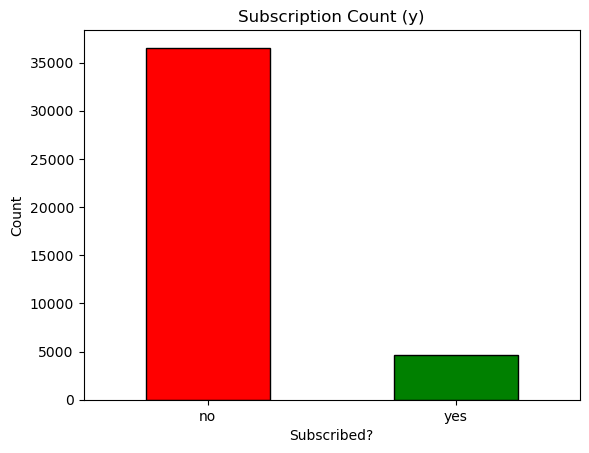

y
no     36535
yes     4639
Name: count, dtype: int64

Insight: Dataset is imbalanced - only ~11% subscribed


In [13]:

df['y'].value_counts().plot(kind='bar', color=['red', 'green'], edgecolor='black')
plt.title('Subscription Count (y)')
plt.xlabel('Subscribed?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print(df['y'].value_counts())
print('\nInsight: Dataset is imbalanced - only ~11% subscribed')

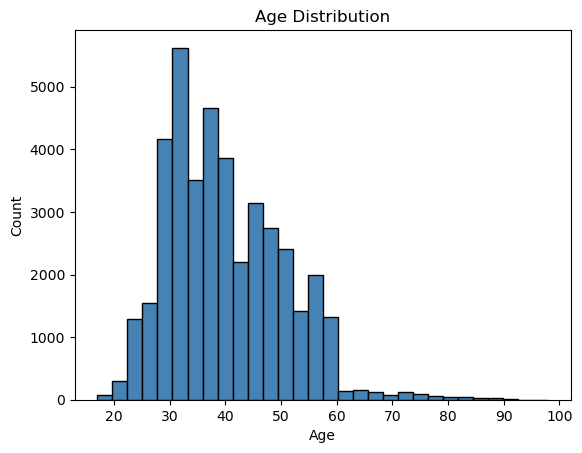

Average age: 40.0
Insight: Most clients are between 25-60 years old


In [14]:

plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

print('Average age:', df['age'].mean().round(1))
print('Insight: Most clients are between 25-60 years old')

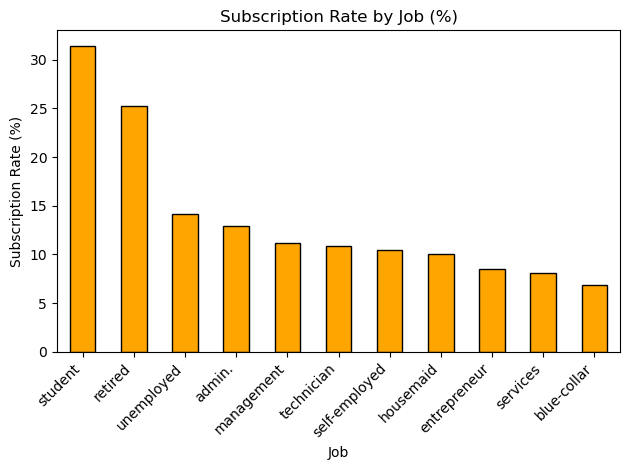

Insight: Students and retired clients have the highest subscription rate


In [15]:

job_sub = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)

job_sub.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Subscription Rate by Job (%)')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Insight: Students and retired clients have the highest subscription rate')

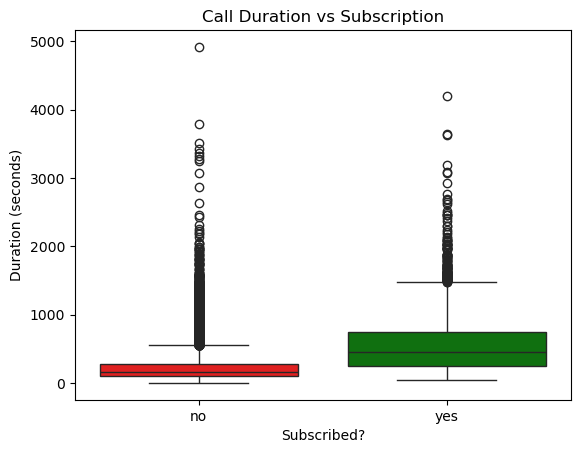

Insight: Clients who subscribed had longer call durations


In [16]:

sns.boxplot(data=df, x='y', y='duration', palette=['red', 'green'])
plt.title('Call Duration vs Subscription')
plt.xlabel('Subscribed?')
plt.ylabel('Duration (seconds)')
plt.show()

print('Insight: Clients who subscribed had longer call durations')

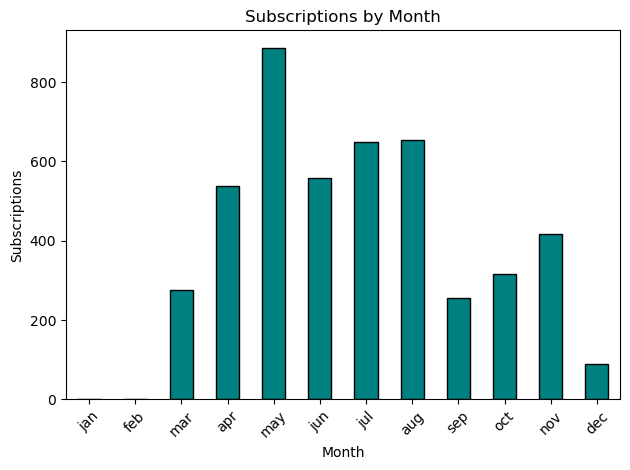

Insight: March, October, and December show high conversion rates


In [17]:

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_counts = df[df['y']=='yes']['month'].value_counts().reindex(month_order).fillna(0)

month_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Subscriptions by Month')
plt.xlabel('Month')
plt.ylabel('Subscriptions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Insight: March, October, and December show high conversion rates')

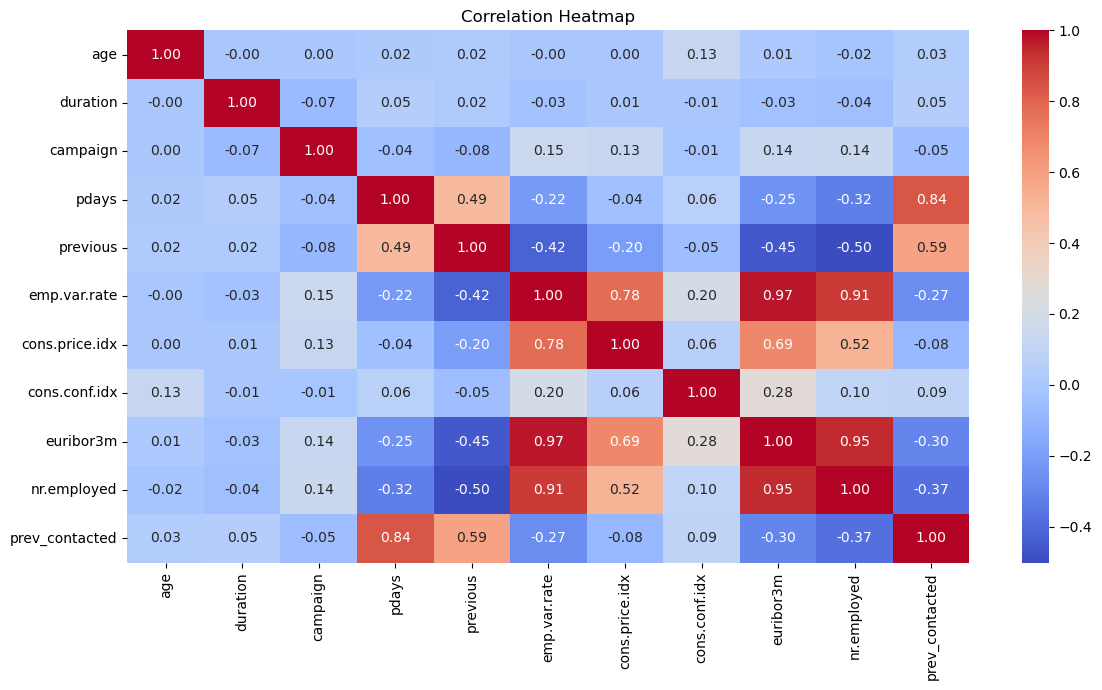

Insight: emp.var.rate, euribor3m, and nr.employed are highly correlated


In [18]:

num_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Insight: emp.var.rate, euribor3m, and nr.employed are highly correlated')

## Step 6 - Feature Encoding



In [19]:

le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])  

print('Target encoding: no=0, yes=1')
print(df['y'].value_counts())

Target encoding: no=0, yes=1
y
0    36535
1     4639
Name: count, dtype: int64


In [20]:

cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome', 'housing', 'loan']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Shape after encoding:', df.shape)
print('All columns are now numeric')

Shape after encoding: (41174, 48)
All columns are now numeric


## Step 7 -  Train-Test & Split

In [21]:

X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (32939, 47)
Test size: (8235, 47)


In [22]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled successfully')

Features scaled successfully


## Step 8 -  Machine Learning Models

In [23]:



lr  = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=5)
nb  = GaussianNB()
svm = SVC(kernel='rbf', probability=True, random_state=42)

lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
nb.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print('All 7 models trained successfully')

All 7 models trained successfully


## Step 9 - Compare All Models

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Logistic Regression' : lr.predict(X_test_scaled),
    'Decision Tree'       : dt.predict(X_test),
    'Support Vector Machine': svm.predict(X_test_scaled),
    'Random Forest'       : rf.predict(X_test),
    'KNN'                 : knn.predict(X_test_scaled),
    'Naive Bayes'         : nb.predict(X_test_scaled),
    'Gradient Boosting'   : gb.predict(X_test)
}


rows = []
for name, y_pred in results.items():
    rows.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4)
    })

results_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(results_df)

                    Model  Accuracy  Precision  Recall  F1-Score
0       Gradient Boosting    0.9162     0.6499  0.5560    0.5993
1           Decision Tree    0.9123     0.6220  0.5657    0.5926
2           Random Forest    0.9115     0.6428  0.4828    0.5514
3     Logistic Regression    0.9093     0.6486  0.4256    0.5140
4  Support Vector Machine    0.9058     0.6357  0.3836    0.4785
5             Naive Bayes    0.8769     0.4547  0.4655    0.4601
6                     KNN    0.8981     0.5851  0.3297    0.4218


In [32]:
# Best model
best_name = results_df.iloc[0]

print('Best Model :', best_name['Model'])
print('Accuracy   :', best_name['Accuracy'])
print('Precision  :', best_name['Precision'])
print('Recall     :', best_name['Recall'])
print('F1-Score   :', best_name['F1-Score'])

Best Model : Gradient Boosting
Accuracy   : 0.9162
Precision  : 0.6499
Recall     : 0.556
F1-Score   : 0.5993


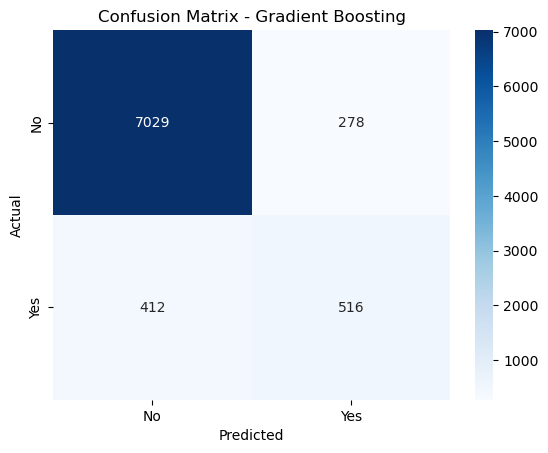

In [26]:

best_pred = results[best_name]
cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:

print(f'Classification Report - {best_name}')
print(classification_report(y_test, best_pred, target_names=['No', 'Yes']))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

          No       0.94      0.96      0.95      7307
         Yes       0.65      0.56      0.60       928

    accuracy                           0.92      8235
   macro avg       0.80      0.76      0.78      8235
weighted avg       0.91      0.92      0.91      8235



## Step 10 - Save Best Model

In [36]:

best_name = results_df.iloc[0]['Model']
best_name = str(best_name).strip()

print("Best Model:", best_name)


model_map = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'Naive Bayes': nb,
    'Support Vector Machine': svm,
    'Gradient Boosting': gb
}


if best_name in model_map:
    best_model = model_map[best_name]
else:
    raise ValueError(f"Model '{best_name}' not found in model_map")


with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print('Saved: best_model.pkl')
print('Saved: scaler.pkl')
print('Saved: label_encoder.pkl')
print('Saved: feature_columns.pkl')

Best Model: Gradient Boosting
Saved: best_model.pkl
Saved: scaler.pkl
Saved: label_encoder.pkl
Saved: feature_columns.pkl


## Step 11 - Predict on New Data

This step shows how to use the saved model to predict for a new client.
The same encoding must be applied to new data as was done during training.

In [37]:

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler_loaded = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    le_loaded = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print('All files loaded successfully')

All files loaded successfully


## Summary

| Step | What we did |
|------|-------------|
| 1 | Imported all libraries |
| 2 | Dataset Gathering and Data Loading (41,188 rows) |
| 3 | Data Claening  |
| 4 | Exported cleaned CSV for Power BI |
| 5 | EDA - 5 plots with insights |
| 6 | Feature Enconding |
| 7 | Traine-Test & split |
| 8 | Machine Learning Models |
| 9 | Compared models  |
| 10 | Saved best model |
| 11 | Predicted on new  data |

**Files created:**
- 'bank.csv' - main dataset used in it
- 'bank_cleaned_powerbi.csv' - for Power BI
- 'best_model.pkl' - trained model
- 'scaler.pkl' - feature scaler
- 'label_encoder.pkl' - target encoder
- 'feature_columns.pkl' - column names for prediction

### Conclusion

In this project, I developed a machine learning model to predict whether a customer will subscribe to a term deposit. By analyzing customer data and comparing different algorithms, I selected the best-performing model for accurate predictions.

This project shows how data can help banks target the right customers, reduce marketing costs, and improve campaign success. It also helped me understand the complete process of data analysis, model building, and deployment.
